# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

As per the link, total instance is `45211`

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [9]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [11]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Find the NULL values of each features

In [15]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## <span style='color:blue'><u>Business Objective</u></span>
Find customers who will subscribe for term deposit and who will not.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### <span style='color:purple'><u>Changing target column y : yes to True and no to False</u></span>

In [23]:
df['y'] = df['y'].replace({'yes': True, 'no': False})

C:\Users\Ansuman\AppData\Local\Temp\ipykernel_8776\2594977560.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['y'] = df['y'].replace({'yes': True, 'no': False})


In [25]:
df.y.unique()

array([False,  True])

In [27]:
X = df.drop('y', axis=1)
y = df['y']
le = LabelEncoder()
y = le.fit_transform(y)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat = df.select_dtypes(include=['object']).columns.tolist()
num = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
trxfer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(drop='first'), cat)
    ]
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Baseline Model should have the following values
Accuracy:  90%
Precision:  60%
Recall:  50%

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [37]:
simpleLRPipeline = Pipeline([
        ('preprocessor', trxfer),
        ('lr', LogisticRegression())
    ])

simpleLRPipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('lr', LogisticRegression())])

### Problem 9: Score the Model

What is the accuracy of your model?

In [40]:
preds = simpleLRPipeline.predict(X_test)
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
print(f'Accuracy: {accuracy: .2f}\nPrecision: {precision: .2f}\nRecall: {recall: .2f}')

Accuracy:  0.91
Precision:  0.67
Recall:  0.43


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

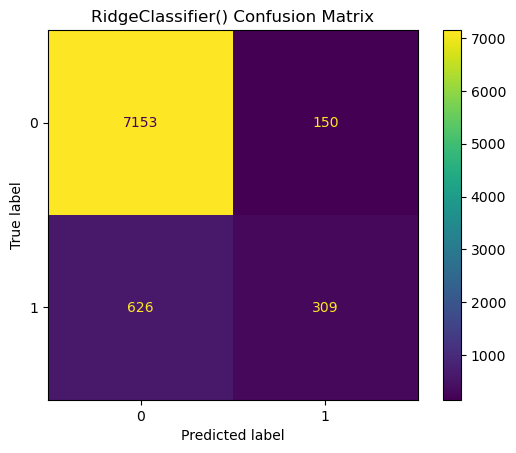

ridge 0.2451953887939453 0.9072837632776934 0.9058023792182569 0.6857142857142857 0.673202614379085 0.3304812834224599 0.3304812834224599


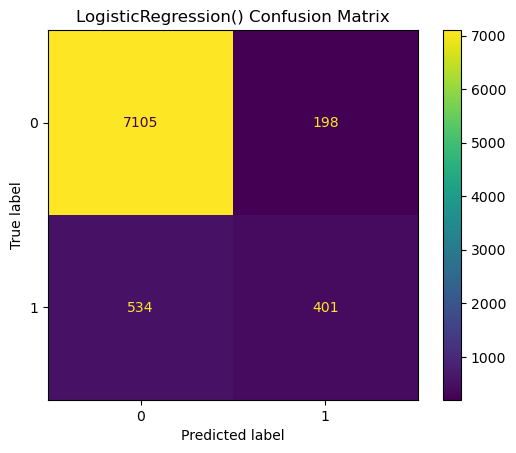

logistic 0.418565034866333 0.9118361153262519 0.911143481427531 0.6724137931034483 0.669449081803005 0.4288770053475936 0.4288770053475936


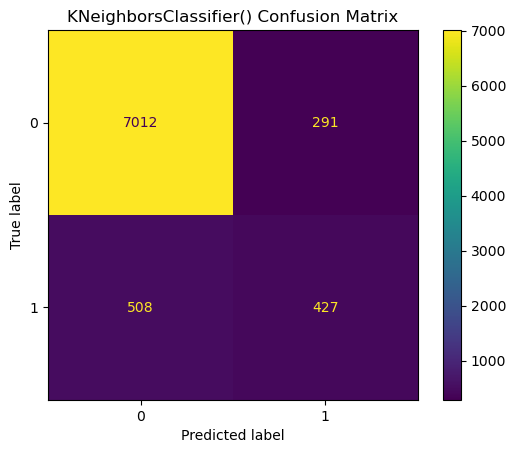

knn 0.13513684272766113 0.9285887708649468 0.9030104394270454 0.7393767705382436 0.5947075208913649 0.4566844919786096 0.4566844919786096


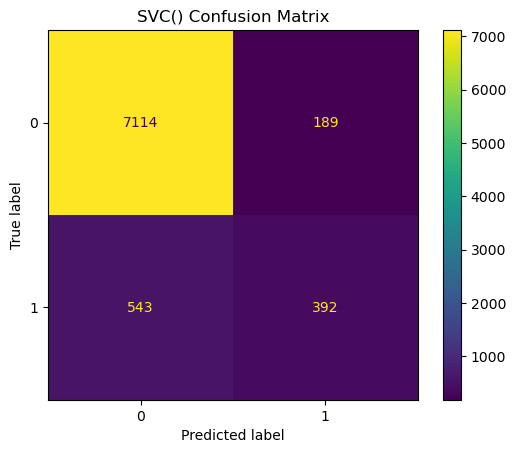

svc 23.667721271514893 0.9216995447647951 0.911143481427531 0.7507802050824788 0.6746987951807228 0.4192513368983957 0.4192513368983957


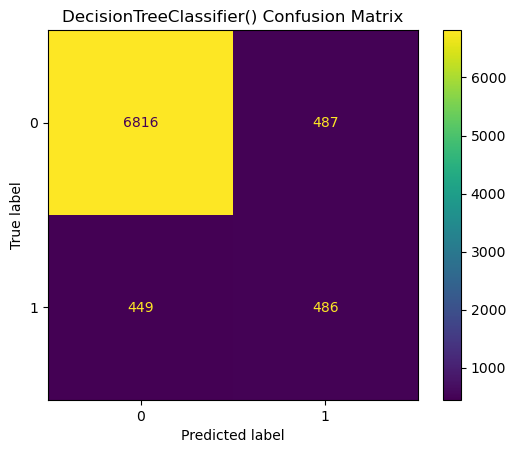

decisiontree 0.45268940925598145 1.0 0.8863801893663511 1.0 0.499486125385406 0.5197860962566845 0.5197860962566845


In [43]:
defaultModels = {
    'ridge': (RidgeClassifier()),
    'logistic': (LogisticRegression()),
    'knn': (KNeighborsClassifier()),
    'svc': (SVC()),
    'decisiontree': (DecisionTreeClassifier())
}

defaultResults = []

for name, (model) in defaultModels.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = (time.time() - start_time)
    
    y_train_predictions = pipeline.predict(X_train)
    y_test_predictions = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_predictions)
    test_accuracy = accuracy_score(y_test, y_test_predictions)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, y_test_predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, y_test_predictions)

    cm = confusion_matrix(y_test, y_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()

    print (name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall)
    # Append the results
    defaultResults.append([name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall])


In [44]:
defaultResults_df = pd.DataFrame(defaultResults, columns=['model', 'fit time','train accuracy', 'test accuracy', 'train precision', 'test precision', 'train recall', 'test recall'])
defaultResults_df.set_index('model', inplace=True)
defaultResults_df

,fit time,train accuracy,test accuracy,train precision,test precision,train recall,test recall
model,,,,,,,
ridge,0.245195,0.907284,0.905802,0.685714,0.673203,0.330481,0.330481
logistic,0.418565,0.911836,0.911143,0.672414,0.669449,0.428877,0.428877
knn,0.135137,0.928589,0.903010,0.739377,0.594708,0.456684,0.456684
svc,23.667721,0.921700,0.911143,0.750780,0.674699,0.419251,0.419251
decisiontree,0.452689,1.000000,0.886380,1.000000,0.499486,0.519786,0.519786


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

<span style='color:purple'> In my opinion gender feature will be helpful. Women has tendency to save more than men. Model performance will be better.</span>

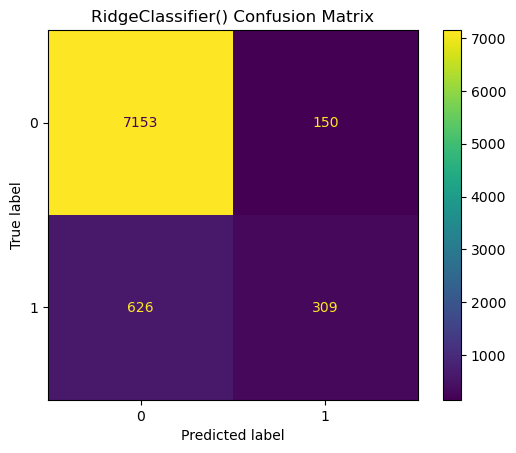

ridge 0.3491323232650757 0.9072837632776934 0.9058023792182569 0.6857142857142857 0.673202614379085 0.5197860962566845 0.3304812834224599 {'ridge__alpha': 1.0}


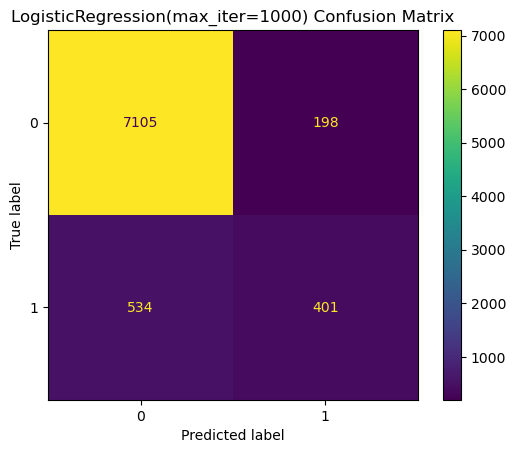

logistic 0.24705178737640382 0.9118361153262519 0.911143481427531 0.6724137931034483 0.669449081803005 0.5197860962566845 0.4288770053475936 {'logistic__C': 1.0}


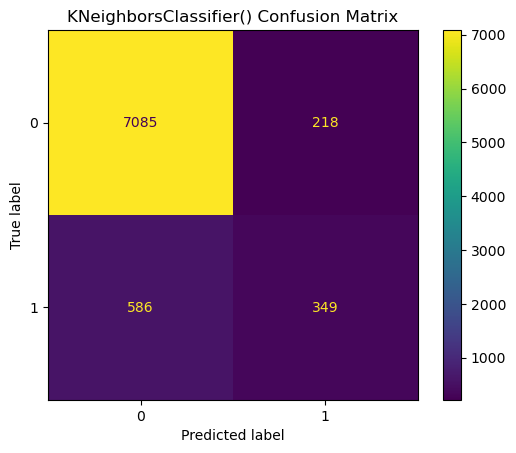

knn 2.8235619479212266 0.91247344461305 0.9024034959941734 0.6849932401982876 0.6155202821869489 0.5197860962566845 0.3732620320855615 {'knn__n_neighbors': 25}


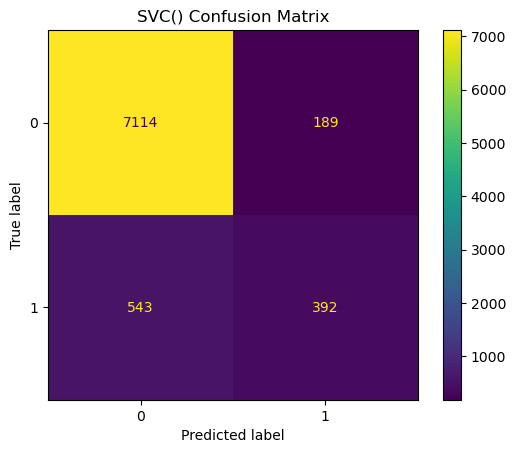

svc 122.06765671571095 0.9216995447647951 0.911143481427531 0.7507802050824788 0.6746987951807228 0.5197860962566845 0.4192513368983957 {'svc__C': 1, 'svc__kernel': 'rbf'}


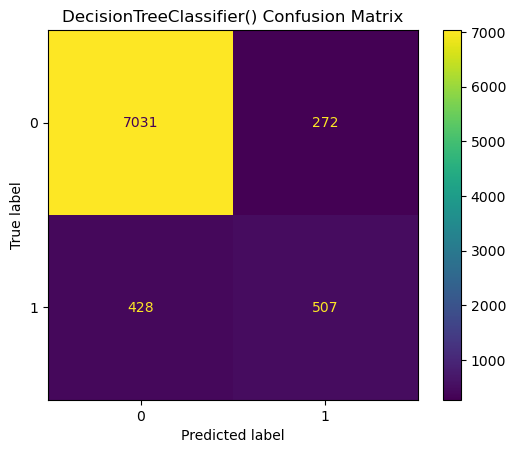

decisiontree 0.4018998384475708 0.9174203338391502 0.9150279193979121 0.657088122605364 0.6508344030808729 0.5197860962566845 0.5422459893048128 {'decisiontree__max_depth': 5}


In [56]:
ridge_hyper = {'ridge__alpha': 10**np.linspace(-5,4,10)}
logistic_hyper = {'logistic__C': 10**np.linspace(-5,4,10)}
knn_hyper = {'knn__n_neighbors': list(range(1, 30, 1))}
decisiontree_hyper = {'decisiontree__max_depth': [5, 10, 15,20,25,30,35,40,45,50]}

models = {
    'ridge': (RidgeClassifier(), ridge_hyper),
    'logistic': (LogisticRegression(max_iter=1000), logistic_hyper),
    'knn': (KNeighborsClassifier(), knn_hyper),
    'svc': (SVC(), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
    'decisiontree': (DecisionTreeClassifier(), decisiontree_hyper )
}

results = []
for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1)

    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    # Get the best estimator
    best_model = grid_search.best_estimator_

    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)

    predictions = best_model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()
    
    y_train_predictions = best_model.predict(X_train)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, predictions)

    print (name, fit_time, train_score, test_score, train_precision, test_precision, train_recall, test_recall, grid_search.best_params_)    
    # Append the results
    results.append([name, fit_time, train_score, test_score, train_precision, test_precision, train_recall, test_recall, grid_search.best_params_])


In [61]:
results_df = pd.DataFrame(results, columns=['model', 'average fit time', 'train score', 'test score', 'train precision', 'test precision', 'train recall', 'test recall', 'hyper'])
results_df.set_index('model', inplace=True)
results_df

,average fit time,train score,test score,train precision,test precision,train recall,test recall,hyper
model,,,,,,,,
ridge,0.349132,0.907284,0.905802,0.685714,0.673203,0.519786,0.330481,{'ridge__alpha': 1.0}
logistic,0.247052,0.911836,0.911143,0.672414,0.669449,0.519786,0.428877,{'logistic__C': 1.0}
knn,2.823562,0.912473,0.902403,0.684993,0.615520,0.519786,0.373262,{'knn__n_neighbors': 25}
svc,122.067657,0.921700,0.911143,0.750780,0.674699,0.519786,0.419251,"{'svc__C': 1, 'svc__kernel': 'rbf'}"
decisiontree,0.401900,0.917420,0.915028,0.657088,0.650834,0.519786,0.542246,{'decisiontree__max_depth': 5}


### The best model is Decision Tree. It performed well in accuracy, precision and recall.